# P12. Dynamic Liquid Layers

A liquid layer can be solved two ways. The **static** form (Saito 1974) drops the liquid's inertia and treats it as hydrostatic, which is accurate at the long periods of most tides. The **dynamic** form (Takeuchi and Saito 1972) keeps the inertia, which matters at short periods and for resonances in thin oceans. The dynamic equations have no density-gradient term, so a dynamic liquid only behaves well if its density profile is consistent with its bulk modulus.

This notebook:

1. Solves the bundled constant-density liquids both ways and shows where the dynamic solve breaks down.
2. Explains why (stratification) and shows the warning TidalPy logs before an unstable solve.
3. Shows that the `_dynamic` bundled worlds, whose liquids follow a pressure-dependent law, stay well behaved.
4. Shows the tolerance a large dynamic core needs at long periods.

In [1]:
%matplotlib inline
import math
import timeit

import numpy as np
# The trapezoid rule: np.trapezoid from NumPy 2.0, np.trapz before it.
trapezoid = getattr(np, "trapezoid", None) or np.trapz
import matplotlib.pyplot as plt

import TidalPy
from TidalPy.Structures import build_world

DAY = 86400.0


def love_k(world, period_days, **kwargs):
    "k2 at one or more forcing periods [days], NaN where a solve fails. Solver warnings stay off unless asked for."
    kwargs.setdefault("warnings", False)
    frequencies = 2.0 * math.pi / (np.asarray(period_days, dtype=float) * DAY)
    return world.calc_love_numbers(frequencies, degree_l=2, **kwargs)["k"]


def set_liquids(world, is_static, is_incompressible=False):
    "Switch every liquid layer, and every layer that melted in places, between the static and dynamic forms."
    # Layers with a liquid zone from melting, such as an ice Ih hydrosphere over its ocean (read from the EOS solve)
    melted_layers = {region[0] for region in world.molten_regions}
    for layer in world.layers:
        if layer.is_liquid or layer.name in melted_layers:
            layer.is_static = is_static
            layer.is_incompressible = is_incompressible


def solved(name):
    world = build_world(name)
    world.solve_eos(raise_on_fail=True)
    return world

## Constant-Density Liquids

Most bundled liquids have a constant density and are solved statically, among them the outer cores of Luna, Mercury, and Earth-Simple. Pluto's and Triton's oceans, the liquid zones of ice Ih hydrospheres, instead follow the pressure-dependent law of MatPack's `water`. Below, Luna and Mercury are solved from half a day to 100 days three ways: static (the reference), dynamic compressible, and dynamic incompressible. The plot shows each dynamic $k_2$'s relative difference from the static one, and the printout gives its range.

luna     dynamic, compressible    smallest difference 2.6e-06 at  3.8 days, largest 1.9e-03, fails from 10.3 days
luna     dynamic, incompressible  smallest difference 1.2e-09 at  4.8 days, largest 4.6e-06, no failures
mercury  dynamic, compressible    smallest difference 1.4e-03 at  1.8 days, largest 2.2e-02, fails from 2.9 days
mercury  dynamic, incompressible  smallest difference 1.1e-06 at 60.4 days, largest 7.4e-03, no failures


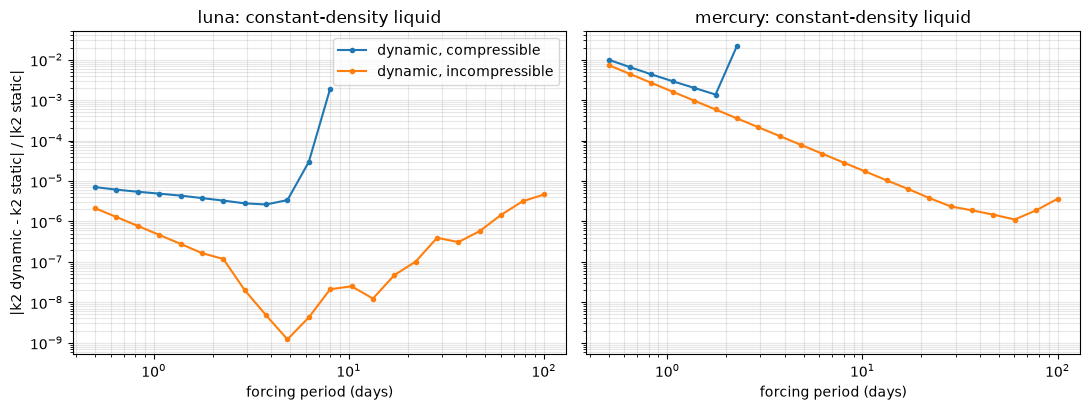

In [2]:
periods = np.logspace(np.log10(0.5), np.log10(100.0), 22)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, name in zip(axes, ("luna", "mercury")):
    world = solved(name)
    curves = {}
    for label, is_static, incompressible in (("static", True, False), ("dynamic, compressible", False, False),
                                             ("dynamic, incompressible", False, True)):
        set_liquids(world, is_static, incompressible)
        curves[label] = love_k(world, periods)
    set_liquids(world, True)
    for label in ("dynamic, compressible", "dynamic, incompressible"):
        diff = np.abs(curves[label] - curves["static"]) / np.abs(curves["static"])
        ax.loglog(periods, diff, "o-", ms=3, label=label)
        smallest = np.nanargmin(diff)
        failed = periods[np.isnan(diff)]  # NaN where the dynamic solve failed
        failures = f"fails from {failed[0]:.1f} days" if failed.size else "no failures"
        print(f"{name:8} {label:24} smallest difference {diff[smallest]:.1e} at {periods[smallest]:4.1f} days, "
              f"largest {np.nanmax(diff):.1e}, {failures}")
    ax.set_title(f"{name}: constant-density liquid")
    ax.set_xlabel("forcing period (days)")
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel("|k2 dynamic - k2 static| / |k2 static|")
axes[0].legend()
plt.tight_layout()
plt.show()

At the shortest periods both dynamic solves differ from the static one because the liquid's inertia matters there. The compressible difference shrinks as the period grows, to $2.6 \times 10^{-6}$ near 4 days for the Moon's core and $1.4 \times 10^{-3}$ near 2 days for Mercury's. Past that, the compressible dynamic solve departs from the static one again, by up to $1.9 \times 10^{-3}$ for the Moon and $2.2 \times 10^{-2}$ for Mercury, and then fails (no points are plotted), from 10 days for the Moon's core and 3 days for Mercury's. The incompressible dynamic solve never fails. Its difference is inertial and falls with period, staying below $5 \times 10^{-6}$ for the Moon's core and reaching $10^{-6}$ near 60 days for Mercury's.

## Why: Stratification

A liquid is neutrally stratified (buoyancy frequency $N^2 = 0$) when its density follows its bulk modulus, $d\rho/dr = -\rho^2 g / K$. A constant-density liquid with a finite bulk modulus has $N^2 = -\rho g^2 / K < 0$. It is unstably stratified, and its dynamic solutions grow through the layer as $e^E$, with

$$E = \frac{\sqrt{\ell(\ell+1)}}{\omega} \int \frac{\sqrt{-N^2}}{r}\, dr.$$

$E$ is proportional to the forcing period. Once $e^E$ amplifies the integration tolerance to order one, the solve is lost. A constant-density incompressible liquid has no bulk-modulus term and is neutral. The cell below calculates the stratification $S = -N^2 / (\rho g^2 / K)$ (0 for neutral, 1 for constant density) and $E$ for Luna's core and for `luna_dynamic`, whose core follows a Birch-Murnaghan law.

luna          S from +1.00e+00 to +1.00e+00;  E at 1 d: 1.9, 10 d: 19.3, 100 d: 193.3
luna_dynamic  S from -1.25e-07 to +1.17e-04;  E at 1 d: 0.0, 10 d: 0.0, 100 d: 0.0


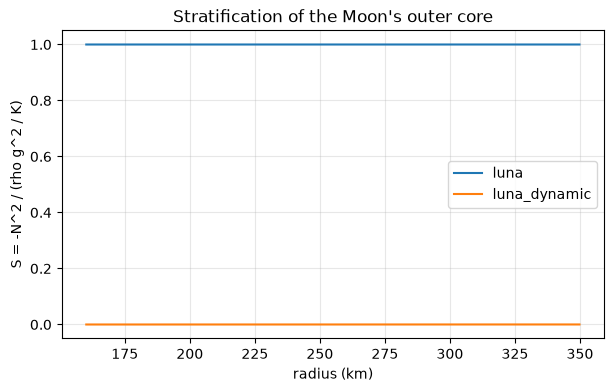

In [3]:
def stratification(world, layer_name, num=2000):
    "S = -N^2 / (rho g^2 / K) through a layer, and E per unit frequency at degree 2."
    layer = world[layer_name]
    span = layer.radius_outer - layer.radius_inner
    r = np.linspace(layer.radius_inner + 1e-3 * span, layer.radius_outer - 1e-3 * span, num)
    state = world.get_state(r)
    rho, g, K = (np.asarray(state[key]) for key in ("density", "gravity", "bulk_modulus"))
    S = 1.0 + (K / (rho ** 2 * g)) * np.gradient(rho, r)
    minus_n2 = S * rho * g ** 2 / K
    E_times_omega = math.sqrt(6.0) * trapezoid(np.sqrt(np.maximum(minus_n2, 0.0)) / r, r)
    return r, S, E_times_omega


fig, ax = plt.subplots(figsize=(7, 4))
for name in ("luna", "luna_dynamic"):
    r, S, E_omega = stratification(solved(name), "outer_core")
    ax.plot(r / 1e3, S, label=name)
    growth = ", ".join(f"{p:g} d: {E_omega / (2 * math.pi / (p * DAY)):.1f}" for p in (1, 10, 100))
    print(f"{name:13s} S from {S.min():+.2e} to {S.max():+.2e};  E at {growth}")
ax.set_xlabel("radius (km)")
ax.set_ylabel("S = -N^2 / (rho g^2 / K)")
ax.set_title("Stratification of the Moon's outer core")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Luna's core has $S = 1$ everywhere, and $E$ reaches about 19 at 10 days, where the dynamic solve failed above. The Birch-Murnaghan core has $S \approx 0$, so $E$ stays near zero.

Before every radial Love solve (`solve_love_numbers`, `calc_tides`, the 3D calls, and `radial_solver`), TidalPy estimates each dynamic liquid layer's error, $\mathrm{rtol}\, e^E$, from its profile. Above 1% it logs one warning per world, to the console and the log file; in a notebook, warnings print below the cell. `TidalPy.capture_log()` also collects the messages logged inside a `with` block in a list, so a script can check for them.

In [4]:
world = solved("luna")
set_liquids(world, is_static=False)

# The warnings print below this cell; capture_log also returns them as a list
with TidalPy.capture_log() as records:
    love_k(world, 30.0, warnings=True)
print(f"{len(records)} warnings logged, stratification warning among them: "
      f"{any('grows unstable' in record for record in records)}")

[TidalPy] [warning] TidalPy: world 'Luna' solves a liquid in layer 'outer_core' with the dynamic equations at a forcing period of 30 days (degree 2), where its solutions grow by about exp(58.1): the estimated relative error is 5.3e+17 at rtol 3e-08. A dynamic liquid whose density does not follow its bulk modulus, such as a constant-density one, grows unstable at long periods: make the layer incompressible, give it a pressure-dependent EOS, or treat it as static. Shown once per world.
[TidalPy] [warning] Radial solver surface boundary condition solve is poorly conditioned (error amplification ~0.0e+00; achievable relative accuracy ~0.0e+00; reciprocal condition number 9.0e-15; requested integration rtol 3.0e-08). Love numbers and surface outputs may be much less accurate than requested. A larger (or automatic) starting radius improves conditioning; tightening tolerances cannot beat the roundoff floor.


2 warnings logged, stratification warning among them: True


## Liquids with an Equation of State: the `_dynamic` Worlds

Four bundled worlds solve their liquid dynamically with a pressure-dependent law. `luna_dynamic` and `mercury_dynamic` are refitted to the same observables as their static counterparts, and `pluto_dynamic` has the structure of `pluto`. `europa_dynamic` instead adds an ocean that the bundled `europa` lacks, which raises its $k_2$ at the orbital period from 0.015 to 0.26.

| World | Liquid | Law |
|---|---|---|
| `luna_dynamic` | Fe-S outer core | Birch-Murnaghan, $K$ and $K'$ of Fe80S20 liquid (Nishida et al. 2020) |
| `mercury_dynamic` | Fe-Si outer core | Birch-Murnaghan, $K$ and $K'$ of Margot et al. (2018) |
| `pluto_dynamic` | Liquid zone of an ice Ih hydrosphere, under its solid zone | MatPack's `water`, Birch-Murnaghan from IAPWS |
| `europa_dynamic` | 115 km water ocean under a 25 km shell | Birch-Murnaghan fitted to IAPWS-95 at 273 K |

Below, each world's dynamic $k_2$ is compared with its static $k_2$ from 1 to 1000 days.

luna_dynamic     difference from 3.2e-09 at    6 days to 1.5e-02, 5.4e-07 at 1 day and 1.5e-02 at 1000 days


mercury_dynamic  difference from 1.2e-06 at   63 days to 1.9e-03, 1.9e-03 at 1 day and 2.3e-05 at 1000 days


pluto_dynamic    difference from 4.3e-08 at 1000 days to 7.9e-03, 7.9e-03 at 1 day and 4.3e-08 at 1000 days
europa_dynamic   difference from 3.1e-08 at  631 days to 1.6e-02, 1.6e-02 at 1 day and 1.7e-07 at 1000 days


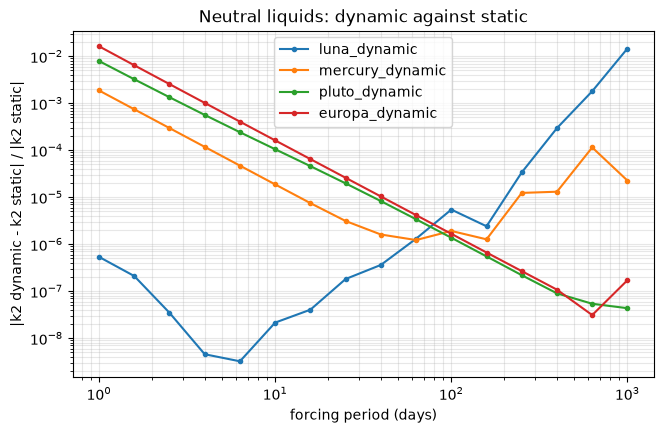

In [5]:
periods = np.logspace(0.0, 3.0, 16)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name in ("luna_dynamic", "mercury_dynamic", "pluto_dynamic", "europa_dynamic"):
    world = solved(name)
    k_dynamic = love_k(world, periods)
    set_liquids(world, is_static=True)
    k_static = love_k(world, periods)
    diff = np.abs(k_dynamic - k_static) / np.abs(k_static)
    ax.loglog(periods, diff, "o-", ms=3, label=name)
    smallest = np.nanargmin(diff)
    print(f"{name:16} difference from {diff[smallest]:.1e} at {periods[smallest]:4.0f} days to {np.nanmax(diff):.1e}, "
          f"{diff[0]:.1e} at 1 day and {diff[-1]:.1e} at 1000 days")
ax.set_xlabel("forcing period (days)")
ax.set_ylabel("|k2 dynamic - k2 static| / |k2 static|")
ax.set_title("Neutral liquids: dynamic against static")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

None of the four breaks down. The dynamic and static solutions differ most at short periods, where inertia matters, and converge as the period grows, since the static form is the long-period limit of a neutral dynamic liquid. Past about 6 days for `luna_dynamic` and 60 days for `mercury_dynamic`, the two large cores, the difference grows again. That growth is mostly integration error of the dynamic solve at the default tolerances, not physics. It shrinks with tighter tolerances, as the next section shows.

## Tolerance at Long Periods in a Large Core

A neutral liquid is stable, but the dynamic equations still recover its tangential displacement by dividing a nearly hydrostatic difference by $\omega^2$. In a large core this costs accuracy and integration steps at long periods. The cell below compares three tolerances, each with `atol` equal to `rtol` (the default is `3e-8` for both), against an `rtol = 1e-12` reference.

In [6]:
world = solved("luna_dynamic")
print(f"{'period':>9s} {'rtol, atol':>10s} {'k2 error':>10s} {'time [ms]':>10s}")
for period in (27.3217, 365.25):
    reference = love_k(world, period, rtol=1e-12, atol=1e-18)
    for tolerance in (1e-6, 3e-8, 1e-9):
        k = love_k(world, period, rtol=tolerance, atol=tolerance)
        seconds = min(timeit.repeat(lambda: love_k(world, period, rtol=tolerance, atol=tolerance), number=3,
                                    repeat=3)) / 3
        print(f"{period:8.2f}d {tolerance:10.0e} {abs(k - reference) / abs(reference):10.1e} {seconds * 1e3:10.2f}")

   period rtol, atol   k2 error  time [ms]
   27.32d      1e-06    5.4e-06       4.74
   27.32d      3e-08    3.9e-07       7.69


   27.32d      1e-09    2.3e-08      12.98


  365.25d      1e-06    8.2e-03      41.98


  365.25d      3e-08    2.8e-04      71.14


  365.25d      1e-09    9.4e-06     112.85


At one month every tolerance is accurate. At one year `1e-6` is off by almost 1%, the default `3e-8` by 3e-4, and `1e-9` by 1e-5. Each factor of about 30 in the tolerances gains a factor of about 30 in accuracy for 1.5 to 1.7 times the time. The thin ocean of `europa_dynamic` and Mercury's core stay accurate at the default out to at least a year.

## Summary

| Liquid | Static | Dynamic |
|---|---|---|
| Constant density, compressible (most shipped liquids) | Accurate at every period | Unstable at long periods. TidalPy warns. |
| Constant density, incompressible | Accurate | Neutral and stable |
| Pressure-dependent law (the `_dynamic` worlds) | Accurate | Neutral and stable. A large core needs tighter tolerances at periods of a year and longer. |

Use a static liquid for long-period tides. Use a dynamic one when inertia matters (short periods, ocean resonances), and give it a density profile consistent with its bulk modulus or make it incompressible.